# 🚀 Practice Day 07

**📅 Date:** 2026-09-19  
**📁 Category:** Phase 2 · 테이블 병합 merge/join (Round 1/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Work with 3 related tables instead of 1 (하나가 아닌 3개의 연결된 테이블 다루기)
- Practice pd.merge() across different key pairs, including a 3-table merge (다양한 key로 pd.merge() 연습, 3개 테이블 병합 포함)
- Answer business questions that require combining tables first (테이블을 합쳐야만 풀 수 있는 질문에 답하기)

---
# 📂 Dataset

**Dataset Name:** E-commerce Customers / Products / Orders (이커머스 고객·상품·주문 데이터)

**Source:** Synthetically generated for practice, fixed random seed (연습용으로 코드에서 직접 생성, seed 고정)

**Description:** Three related tables instead of one. `customers_df` (45 customers: NYC neighborhood, signup date, membership tier), `products_df` (23 products across 5 categories: Electronics, Home & Kitchen, Sports & Outdoors, Beauty, Books; unit_price in USD), and `orders_df` (280 orders, each linking one customer_id and one product_id). `orders_df` is the "fact" table; the other two are lookup tables you'll need to merge in.
(테이블 1개가 아니라 3개입니다. customers_df(고객 45명: 뉴욕 동네·가입일·등급), products_df(상품 23개, 5개 카테고리, 단가 USD), orders_df(주문 280건, 각 주문은 customer_id 1개와 product_id 1개를 참조). orders_df가 중심 테이블이고, 나머지 둘은 merge로 붙여야 하는 참조 테이블입니다.)

## Dataset Preview

In [1]:
# Dataset Preview
import pandas as pd
import numpy as np
from IPython.display import display

np.random.seed(42)

# --- customers_df ---
n_customers = 45
first_names = ['James', 'Emma', 'Liam', 'Olivia', 'Noah', 'Ava', 'Ethan', 'Sophia', 'Mason', 'Mia',
                'Lucas', 'Amelia', 'Henry', 'Harper', 'Alexander', 'Isabella', 'Benjamin', 'Charlotte', 'Daniel', 'Evelyn']
last_names = ['Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Garcia', 'Miller', 'Davis', 'Wilson', 'Taylor']
customer_names = [f'{np.random.choice(first_names)} {np.random.choice(last_names)}' for _ in range(n_customers)]
regions = ['SoHo', 'Williamsburg', 'Midtown', 'Chelsea', 'Astoria', 'Upper West Side']
region_weights = [0.32, 0.26, 0.13, 0.09, 0.10, 0.10]

customers_df = pd.DataFrame({
    'customer_id': [f'CUST-{i+1:03d}' for i in range(n_customers)],
    'customer_name': customer_names,
    'region': np.random.choice(regions, size=n_customers, p=region_weights),
    'signup_date': pd.to_datetime('2024-01-01') + pd.to_timedelta(np.random.randint(0, 550, n_customers), unit='D'),
    'membership_tier': np.random.choice(['Regular', 'Silver', 'Gold'], size=n_customers, p=[0.55, 0.30, 0.15]),
})

# --- products_df ---
product_catalog = {
    'Electronics': [('Wireless Mouse', 25), ('Bluetooth Speaker', 45), ('USB-C Hub', 32), ('Webcam', 55), ('Desk Lamp', 28)],
    'Home & Kitchen': [('Ceramic Mug Set', 18), ('Non-stick Pan', 39), ('Storage Container Set', 22), ('Electric Kettle', 42), ('Cutting Board', 15)],
    'Sports & Outdoors': [('Yoga Mat', 24), ('Water Bottle', 12), ('Resistance Bands', 16), ('Running Shorts', 21), ('Foam Roller', 27)],
    'Beauty': [('Facial Cleanser', 14), ('Moisturizer', 26), ('Sunscreen', 18), ('Lip Balm Set', 9)],
    'Books': [('Business Strategy Guide', 19), ('Novel Collection', 15), ('Cookbook', 21), ('Self-Help Book', 13)],
}
prod_rows = []
pid = 1
for cat, items in product_catalog.items():
    for name, price in items:
        prod_rows.append({'product_id': f'PROD-{pid:02d}', 'product_name': name, 'category': cat, 'unit_price': price})
        pid += 1
products_df = pd.DataFrame(prod_rows)

# --- orders_df ---
n_orders = 280
customer_popularity = np.random.dirichlet(np.ones(n_customers) * 1.5)
product_popularity = np.random.dirichlet(np.ones(len(products_df)) * 1.5)

orders_df = pd.DataFrame({
    'order_id': [f'ORD-{i+1:05d}' for i in range(n_orders)],
    'customer_id': np.random.choice(customers_df['customer_id'], size=n_orders, p=customer_popularity),
    'product_id': np.random.choice(products_df['product_id'], size=n_orders, p=product_popularity),
    'order_date': np.random.choice(pd.date_range('2026-01-01', '2026-06-30', freq='D'), size=n_orders),
    'quantity': np.random.choice([1, 2, 3, 4, 5], size=n_orders, p=[0.45, 0.30, 0.15, 0.07, 0.03]),
})
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
orders_df = orders_df.sort_values('order_date').reset_index(drop=True)

print('customers_df:', customers_df.shape)
display(customers_df.head())
print('\nproducts_df:', products_df.shape)
display(products_df.head())
print('\norders_df:', orders_df.shape)
display(orders_df.head())

customers_df: (45, 5)


,customer_id,customer_name,region,signup_date,membership_tier
0,CUST-001,Ethan Brown,Chelsea,2025-05-20,Regular
1,CUST-002,Alexander Davis,Chelsea,2024-12-13,Gold
2,CUST-003,Ethan Taylor,SoHo,2025-04-17,Regular
3,CUST-004,Daniel Miller,Williamsburg,2024-08-18,Silver
4,CUST-005,Lucas Davis,SoHo,2024-07-08,Silver



products_df: (23, 4)


,product_id,product_name,category,unit_price
0,PROD-01,Wireless Mouse,Electronics,25
1,PROD-02,Bluetooth Speaker,Electronics,45
2,PROD-03,USB-C Hub,Electronics,32
3,PROD-04,Webcam,Electronics,55
4,PROD-05,Desk Lamp,Electronics,28



orders_df: (280, 5)


,order_id,customer_id,product_id,order_date,quantity
0,ORD-00186,CUST-037,PROD-07,2026-01-03,1
1,ORD-00248,CUST-001,PROD-09,2026-01-03,1
2,ORD-00229,CUST-027,PROD-10,2026-01-03,1
3,ORD-00153,CUST-016,PROD-19,2026-01-04,2
4,ORD-00216,CUST-027,PROD-13,2026-01-04,5


## Dataset Information

In [2]:
# Dataset Information
for name, d in [('customers_df', customers_df), ('products_df', products_df), ('orders_df', orders_df)]:
    print(f'=== {name}: {d.shape} ===')
    d.info()
    print()

=== customers_df: (45, 5) ===
<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      45 non-null     str           
 1   customer_name    45 non-null     str           
 2   region           45 non-null     str           
 3   signup_date      45 non-null     datetime64[us]
 4   membership_tier  45 non-null     str           
dtypes: datetime64[us](1), str(4)
memory usage: 1.9 KB

=== products_df: (23, 4) ===
<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_id    23 non-null     str  
 1   product_name  23 non-null     str  
 2   category      23 non-null     str  
 3   unit_price    23 non-null     int64
dtypes: int64(1), str(3)
memory usage: 868.0 bytes

=== orders_df: (280, 5) ===
<class

---
# ❓ Business Questions

1. For each order, what is the customer's name and region? (각 주문에 대해 고객명과 지역은?)
2. For each order, what is the product name, category, and total price (unit_price × quantity)? (각 주문의 상품명, 카테고리, 총 금액(단가×수량)은?)
3. What is the total revenue by customer membership tier? (고객 등급별 총 매출은?)
4. How does total revenue compare across product categories? (상품 카테고리별 총 매출을 비교하면 어떤 모습인가?)
5. How does order count compare across customer regions? (고객 지역별 주문 건수를 비교하면 어떤 모습인가?)

---
# 🛠 Skills Used
- [x] Python
- [ ] NumPy
- [x] Pandas — `merge`, `groupby`, `sort_values`
  (merge, groupby, 정렬)
- [ ] SQL
- [x] Matplotlib
- [ ] Other: 

---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0 on all three tables
  (세 테이블 모두 결측 없음)
- [x] Duplicate Rows — 0
  (중복 행 없음. 고객명 unique는 43, id는 45)
- [x] Wrong Data Types — ids/names/region/tier/category are text; unit_price and quantity are int; dates are datetime
  (텍스트, 가격·수량은 정수, 날짜는 datetime)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [3]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("===== customers_df =====")
print("Missing values")
print(customers_df.isnull().sum())
print("\nDuplicate rows:", customers_df.duplicated().sum())
print("\nDtypes")
print(customers_df.dtypes)
print("\nColumn names")
print(customers_df.columns.tolist())
obj_cols = customers_df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(customers_df[obj_cols].nunique())
print()

print("===== products_df =====")
print("Missing values")
print(products_df.isnull().sum())
print("\nDuplicate rows:", products_df.duplicated().sum())
print("\nDtypes")
print(products_df.dtypes)
print("\nColumn names")
print(products_df.columns.tolist())
obj_cols = products_df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(products_df[obj_cols].nunique())
print()

print("===== orders_df =====")
print("Missing values")
print(orders_df.isnull().sum())
print("\nDuplicate rows:", orders_df.duplicated().sum())
print("\nDtypes")
print(orders_df.dtypes)
print("\nColumn names")
print(orders_df.columns.tolist())
obj_cols = orders_df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(orders_df[obj_cols].nunique())
print()


===== customers_df =====
Missing values
customer_id        0
customer_name      0
region             0
signup_date        0
membership_tier    0
dtype: int64

Duplicate rows: 0

Dtypes
customer_id                   str
customer_name                 str
region                        str
signup_date        datetime64[us]
membership_tier               str
dtype: object

Column names
['customer_id', 'customer_name', 'region', 'signup_date', 'membership_tier']

Text columns — unique counts
customer_id        45
customer_name      43
region              6
membership_tier     3
dtype: int64

===== products_df =====
Missing values
product_id      0
product_name    0
category        0
unit_price      0
dtype: int64

Duplicate rows: 0

Dtypes
product_id        str
product_name      str
category          str
unit_price      int64
dtype: object

Column names
['product_id', 'product_name', 'category', 'unit_price']

Text columns — unique counts
product_id      23
product_name    23
category        

---
# 📊 Analysis

## Question 1

**Question:** For each order, what is the customer's name and region? (각 주문에 대해 고객명과 지역은?)

**Result:** After `merge` on `customer_id`, the table has **280** rows (one per order) with `customer_name` and `region`. The same name repeats when that customer ordered more than once (e.g. Harper Smith, Midtown). Cleaning unique counts: orders use **42** of **45** customer_ids.
(merge 후 280행. 같은 고객이 여러 주문에 반복. 주문에 나온 고객 id는 45명 중 42명)

**Insight:** Q1 is a lookup at order grain, not a customer list. Do not count repeated names as extra people. Three customers never appear because they have no order row.
(Q1은 주문 단위 조회. 이름이 반복되어도 사람 수가 늘어난 것이 아님. 주문 없는 고객 3명은 안 나옴)

In [8]:
# Question 1: Merge orders_df with customers_df on 'customer_id', then look at customer_name and region
# (orders_df와 customers_df를 customer_id 기준으로 merge)

data = pd.merge(orders_df, customers_df, on='customer_id', how='left')

display(data[['customer_name', 'region']])

,customer_name,region
0,Sophia Jones,SoHo
1,Ethan Brown,Chelsea
2,Harper Smith,Midtown
3,Evelyn Wilson,SoHo
4,Harper Smith,Midtown
...,...,...
275,Amelia Davis,SoHo
276,Mia Brown,SoHo
277,Liam Jones,Chelsea
278,Lucas Davis,SoHo


## Question 2

**Question:** For each order, what is the product name, category, and total price (unit_price × quantity)? (각 주문의 상품명, 카테고리, 총 금액(단가×수량)은?)

**Result:** After `merge` on `product_id`, **280** rows. `total_price` = `unit_price * quantity`. Example: Resistance Bands **$16 x 5 = $80**; Non-stick Pan **$39 x 1 = $39**.
(상품 merge 후 280행. 총액 = 단가 x 수량. 예: 밴드 16x5=80, 팬 39x1=39)

**Insight:** Unit price is not the order value. A low-price SKU with qty 5 can beat a higher-price qty 1. Chart 1 is this line total rolled up by category.
(단가가 주문 금액이 아님. 싼 상품도 수량이 많으면 더 큼. 차트 1은 이 금액을 카테고리로 합친 것)

In [ ]:
# Question 2: Merge orders_df with products_df on 'product_id', then compute total_price = unit_price * quantity
# (orders_df와 products_df를 product_id 기준으로 merge 후 total_price 계산)

data = pd.merge(orders_df, products_df, on='product_id', how='left')
data['total_price'] = data['unit_price'] * data['quantity']

display(data[['product_name', 'category', 'unit_price', 'quantity', 'total_price']])


,product_name,category,unit_price,quantity,total_price
0,Non-stick Pan,Home & Kitchen,39,1,39
1,Electric Kettle,Home & Kitchen,42,1,42
2,Cutting Board,Home & Kitchen,15,1,15
3,Lip Balm Set,Beauty,9,2,18
4,Resistance Bands,Sports & Outdoors,16,5,80
...,...,...,...,...,...
275,Foam Roller,Sports & Outdoors,27,1,27
276,Self-Help Book,Books,13,1,13
277,Storage Container Set,Home & Kitchen,22,2,44
278,Sunscreen,Beauty,18,3,54


## Question 3

**Question:** What is the total revenue by customer membership tier? (고객 등급별 총 매출은?)

**Result:** Total revenue (USD): Regular **$5,300**, Gold **$4,795**, Silver **$3,054**.
(등급별 총 매출: Regular 5300, Gold 4795, Silver 3054)

**Insight:** Regular is #1 as a group, but Gold is close. Do not read Regular as the best customers and Gold as a leftover. This table is tier totals, not revenue per person.
(Regular가 합은 1등이지만 Gold와 가까움. Regular를 우수 고객, Gold를 나머지로 보면 안 됨. 1인당이 아니라 등급 합)

In [ ]:
# Question 3: Merge all three tables (orders + customers + products), then groupby membership_tier
# (세 테이블을 모두 merge한 뒤 membership_tier 기준으로 groupby)

data = pd.merge(orders_df, customers_df, on='customer_id', how='left')
data = pd.merge(data, products_df, on='product_id', how='left')
data['total_price'] = data['unit_price'] * data['quantity']

data = data.groupby('membership_tier')['total_price'].sum().sort_values(ascending=False)

display(data)


membership_tier
Regular    5300
Gold       4795
Silver     3054
Name: total_price, dtype: int64

---
# 📈 Visualization

**Chart 1:** Total revenue by product category (bar chart) - 카테고리별 총 매출

**Interpretation:** Home & Kitchen leads (**$4,997**), then Sports & Outdoors (**$2,954**). Books **$1,779**, Electronics **$1,752**, Beauty **$1,667**. Electronics is not the revenue leader.
(Home & Kitchen이 1위 약 5000. Sports가 2위. Electronics는 단가가 높아 보여도 매출 1등이 아님)

---

**Chart 2:** Order count by customer region (bar chart) - 지역별 주문 건수

**Interpretation:** SoHo is the tallest bar (**97**). Midtown **51**, Chelsea **44**, Williamsburg **42**, Astoria **40**. Upper West Side is **6**. This is order count, not revenue.
(SoHo 97건이 1위. Upper West Side는 6건. 차트 2는 건수지 매출이 아님)

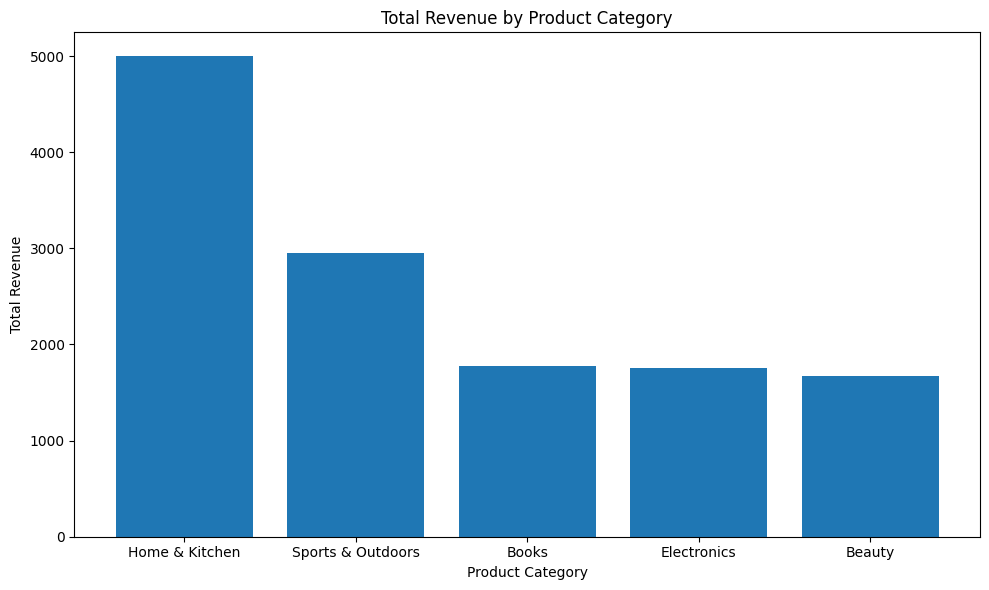

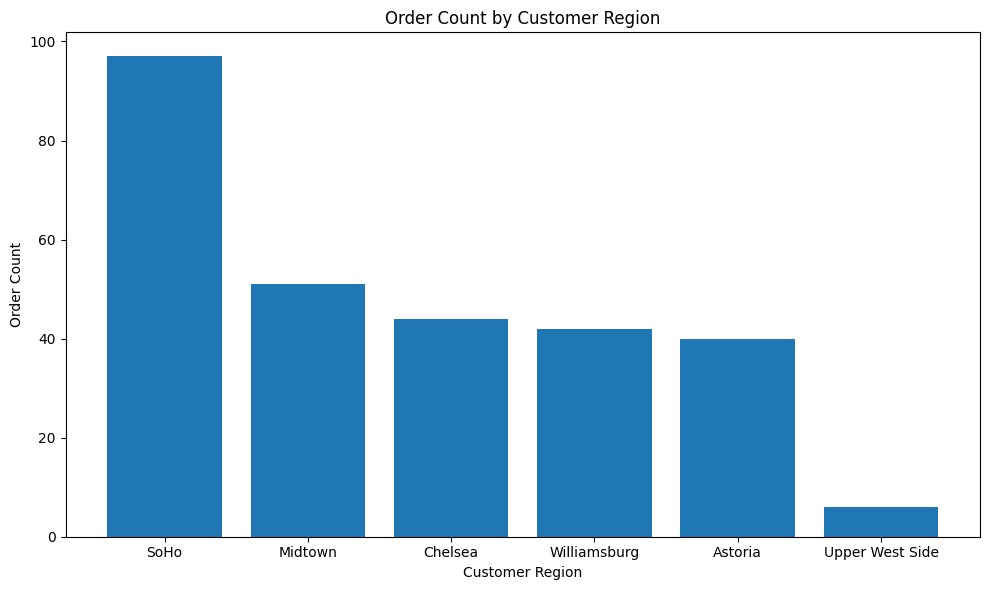

In [19]:
# Visualization
import matplotlib.pyplot as plt
# import seaborn as sns

# Chart 1: Total revenue by product category (bar chart) - merge orders_df + products_df first
data = pd.merge(orders_df, products_df, on='product_id', how='left')
data['total_price'] = data['unit_price'] * data['quantity']
data = data.groupby('category')['total_price'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(data.index, data.values)
ax.set_title('Total Revenue by Product Category')
ax.set_xlabel('Product Category')
ax.set_ylabel('Total Revenue')
plt.tight_layout()
plt.show()

# Chart 2: Order count by customer region (bar chart) - merge orders_df + customers_df first
data = pd.merge(orders_df, customers_df, on='customer_id', how='left')
data = data.groupby('region')['order_id'].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(data.index, data.values)
ax.set_title('Order Count by Customer Region')
ax.set_xlabel('Customer Region')
ax.set_ylabel('Order Count')
plt.tight_layout()
plt.show()


---
# 💼 Business Insights
**What did I discover?**

- Orders do not have name, region, or price. `merge` on `customer_id` / `product_id` is required first.
  (주문 테이블에 이름·지역·가격이 없음. 먼저 merge)
- Regular has the most revenue (**$5,300**) but Gold is close (**$4,795**).
  (Regular 합이 커도 Gold와 가까움)
- Home & Kitchen leads category revenue (**$4,997**). SoHo leads order count (**97**); Upper West Side is **6**.
  (카테고리 매출은 Home & Kitchen. 주문 건수는 SoHo, UWS는 6건)
 

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Do not treat the Q1 name list as unique customers. It is **280** orders, and **3** customers never ordered.
   (Q1 이름 목록을 고객 수로 세지 말 것. 280건 주문이고, 미주문 고객 3명)
2. Do not give Regular all of the tier budget because they are #1. Gold is **$4,795** vs Regular **$5,300**.
   (Regular 1등이라고 Gold를 나머지로 두지 말 것)
3. Do not stock as if Electronics is the money category, and do not staff Upper West Side like SoHo. Chart 1 is $, Chart 2 is counts.
   (Electronics를 매출 1등으로 보지 말 것. UWS를 SoHo처럼 운영하지 말 것. 차트 1은 금액, 차트 2는 건수)
 

---
# ❌ Mistakes
**What mistakes did I make today?**

- Q1 and Q2 look like finished answers, but they are row dumps until you `groupby`.
  (Q1·Q2는 행 목록. groupby 전까지는 합이 아님)
- Chart 1 is revenue and Chart 2 is order count. The bars are not the same metric.
  (차트 1은 매출, 차트 2는 건수. 막대를 같은 지표로 비교하면 안 됨)
- `how='left'` keeps all orders. Customers with no orders do not show up in an orders-left merge.
  (left는 주문은 다 남김. 주문 없는 고객은 안 나옴)
 

---
# ✅ What I Learned
**Today's biggest lesson**

- `pd.merge(orders_df, customers_df, on='customer_id')` attaches name and region. `on='product_id'` attaches price and category.
  (customer_id merge는 이름·지역. product_id merge는 가격·카테고리)
- `how='left'` keeps every order row. Then `total_price = unit_price * quantity`.
  (left는 주문 행 유지. 총액은 단가 x 수량)
- A 3-table merge, then `groupby` + `sum`, is Q3. Chart 1 groups by category; Chart 2 counts by region.
  (세 테이블 merge 후 groupby 합이 Q3. 차트 1은 카테고리 합, 차트 2는 지역 건수)
 

---
# 🧠 Reflection

**What was difficult?**
Merging three tables in the right order, and not stopping at the Q1/Q2 row lists.
(세 테이블 merge 순서, Q1·Q2 목록에서 멈추지 않기)

**Why?**
Name, region, and unit_price live on lookup tables. `orders_df` only has ids.
(이름·지역·단가가 주문 테이블에 없음. id만 있음)

**How did I solve it?**
`merge` on `customer_id`, then `merge` on `product_id`, then `groupby` for Q3 and the charts.
(customer_id merge, product_id merge, 그다음 groupby)

**What would I do differently next time?**
Check grain first (order vs customer). Check whether the chart is $ or counts before comparing bars.
(먼저 단위: 주문 vs 고객. 차트는 금액인지 건수인지)


---
# ⭐ Self Evaluation

**Understanding**  
★★★★★★★☆☆☆  
Merge keys worked. Order level vs customer level needed help.  
(merge key는 됨. 주문 단위 vs 고객 단위는 도움 필요)

**Confidence**  
★★★★★★☆☆☆☆  

**Difficulty**  
★★★★★★☆☆☆☆  
Telling whether a table is at order level was harder than the query.  
(쿼리보다 표가 주문 단위인지 읽는 게 더 어려웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 08 — SQL JOIN / CASE WHEN / subquery
  (SQL JOIN, CASE WHEN, 서브쿼리) 